# Predicting Wine Quality from Chemical Properties
Authors: Justin Kim, Aryan Arora, Shuri Yamamoto, Erhan Asad Javed

## Import & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from ucimlrepo import fetch_ucirepo 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

<br>

## Summary

TODO

<br>

## Introduction

Wine is one of the most widely consumed beverages in the world, valued for its taste, cultural significance, and sensory qualities. Determining wine quality, even for expert tasters, can be challenging. Vinho verde wine is produced in the Minho region of northern Portugal and is known for its light and fresh characteristics. In this project, we focus on white vinho verde wine and investigate whether its physicochemical properties can be used to predict wine quality [2]. To answer this question, we use a dataset from the UC Irvine Machine Learning Repository [1] and apply predictive modeling techniques to explore relationships between chemical measurements and sensory quality scores.

### Dataset Description

The Wine Quality dataset contains physicochemical measurements of Portuguese *Vinho Verde* wines. Each observation corresponds to a wine sample that was evaluated using laboratory tests and sensory analysis by wine experts.

The dataset includes 11 physicochemical input variables (e.g., acidity, pH, alcohol content) and 1 target variable representing wine quality. Wine quality scores were assigned as the median of at least three expert evaluations, with ratings ranging from 0 (very bad) to 10 (excellent).

There are two datasets exist in the Wine Quality dataset collection:
- Red wine: 1,599 observations  
- White wine: 4,898 observations  

For this analysis, we only use the white wine dataset as it contains the most number of samples.
<br>

#### Feature Description

| Name | Role | Type | Units | Description | Missing Values |
|-----|-----|-----|-----|-----|-----|
| fixed_acidity | Feature | Continuous | g/dm³ | Fixed acids (primarily tartaric acid) that do not evaporate easily. | No |
| volatile_acidity | Feature | Continuous | g/dm³ | Amount of acetic acid in wine; high levels can lead to an unpleasant vinegar taste. | No |
| citric_acid | Feature | Continuous | g/dm³ | Citric acid content, which can add freshness and flavor to wine. | No |
| residual_sugar | Feature | Continuous | g/dm³ | Amount of sugar remaining after fermentation stops. | No |
| chlorides | Feature | Continuous | g/dm³ | Salt content in the wine. | No |
| free_sulfur_dioxide | Feature | Continuous | mg/dm³ | Free form of sulfur dioxide that prevents microbial growth and oxidation. | No |
| total_sulfur_dioxide | Feature | Continuous | mg/dm³ | Total amount of sulfur dioxide (free + bound forms). | No |
| density | Feature | Continuous | g/cm³ | Density of the wine, influenced by alcohol and sugar content. | No |
| pH | Feature | Continuous | – | Acidity level of the wine; lower values indicate higher acidity. | No |
| sulphates | Feature | Continuous | g/dm³ | Potassium sulphate concentration, contributing to sulfur dioxide levels and preservation. | No |
| alcohol | Feature | Continuous | % (vol) | Alcohol content of the wine. | No |
| quality | Target | Integer | Score (0–10) | Wine quality score based on expert sensory evaluation. | No

<br>

## Methods & Results

### Exploratory Data Analysis

#### Loading the Dataset

The Wine Quality dataset is retrieved directly from the **UCI Machine Learning Repository** using the `ucimlrepo` library. The dataset is returned with the features (input variables) and the target variable (wine quality score) stored separately.  

To recreate the original dataset structure, we combine the features and target into a single DataFrame using `pd.concat()`. This produces a table where each row represents a wine sample and each column represents a physicochemical property or the quality score.

In [2]:
# Fetch dataset
wine_quality = fetch_ucirepo(id=186)

# Features and target
X = wine_quality.data.features
y = wine_quality.data.targets

df = pd.concat([X, y], axis=1)

df = df.iloc[1599:]

In [3]:
df.shape

(4898, 12)

#### Inspecting the dataset structure

We examine the basic structure of the dataset by checking its shape, column names, data types, and whether any values are missing.

- `df.shape` shows the number of rows and columns in the dataset.
- `df.columns` lists all variable names.
- `df.info()` provides the data type of each column and a summary of non-null values.
- `df.isnull().sum()` counts the number of missing values in each column.
- `df.describe()` provides summary statistics such as mean, standard deviation, and range for numerical variables.

In [4]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nData types and info:")
print(df.info())

Shape of dataset: (4898, 12)

Column names:
Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

Data types and info:
<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 1599 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         4898 non-null   float64
 1   volatile_acidity      4898 non-null   float64
 2   citric_acid           4898 non-null   float64
 3   residual_sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free_sulfur_dioxide   4898 non-null   float64
 6   total_sulfur_dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [6]:
print("Summary statistics:")
print(df.describe())

Summary statistics:
       fixed_acidity  volatile_acidity  citric_acid  residual_sugar  \
count    4898.000000       4898.000000  4898.000000     4898.000000   
mean        6.854788          0.278241     0.334192        6.391415   
std         0.843868          0.100795     0.121020        5.072058   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.300000          0.210000     0.270000        1.700000   
50%         6.800000          0.260000     0.320000        5.200000   
75%         7.300000          0.320000     0.390000        9.900000   
max        14.200000          1.100000     1.660000       65.800000   

         chlorides  free_sulfur_dioxide  total_sulfur_dioxide      density  \
count  4898.000000          4898.000000           4898.000000  4898.000000   
mean      0.045772            35.308085            138.360657     0.994027   
std       0.021848            17.007137             42.498065     0.002991   
min       0.009000          

#### Distribution of wine quality

We visualize the distribution of the target variable `quality` using a bar chart. The values are counted using `value_counts()` and sorted by quality score to show how many wines fall into each rating category. This helps us understand how wine quality scores are distributed across the dataset.

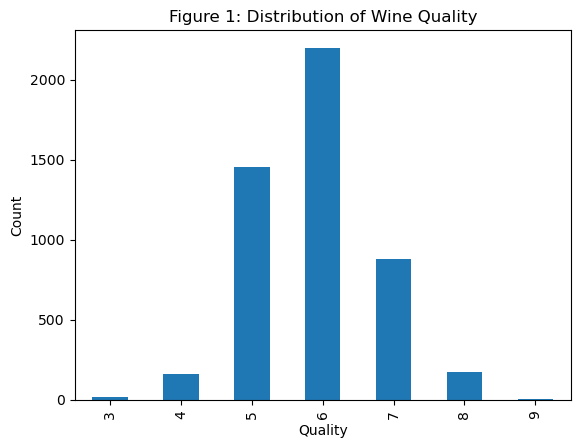

In [7]:
plt.figure()
df["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Figure 1: Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

Figure 1 shows that the distribution of wine quality scores is concentrated around the middle values. Most wines are rated 5, 6, or 7, with quality 6 being the most frequent. Very few wines receive extreme ratings such as 3 or 9, indicating that the dataset contains mostly average-quality wines and relatively few very poor or excellent samples.

### Feature distributions

We generate histograms for each numerical feature in the dataset using `df.hist()`. This allows us to visualize the distribution of values for each variable and observe patterns such as skewness, spread, and potential outliers across the physicochemical properties of the wines.

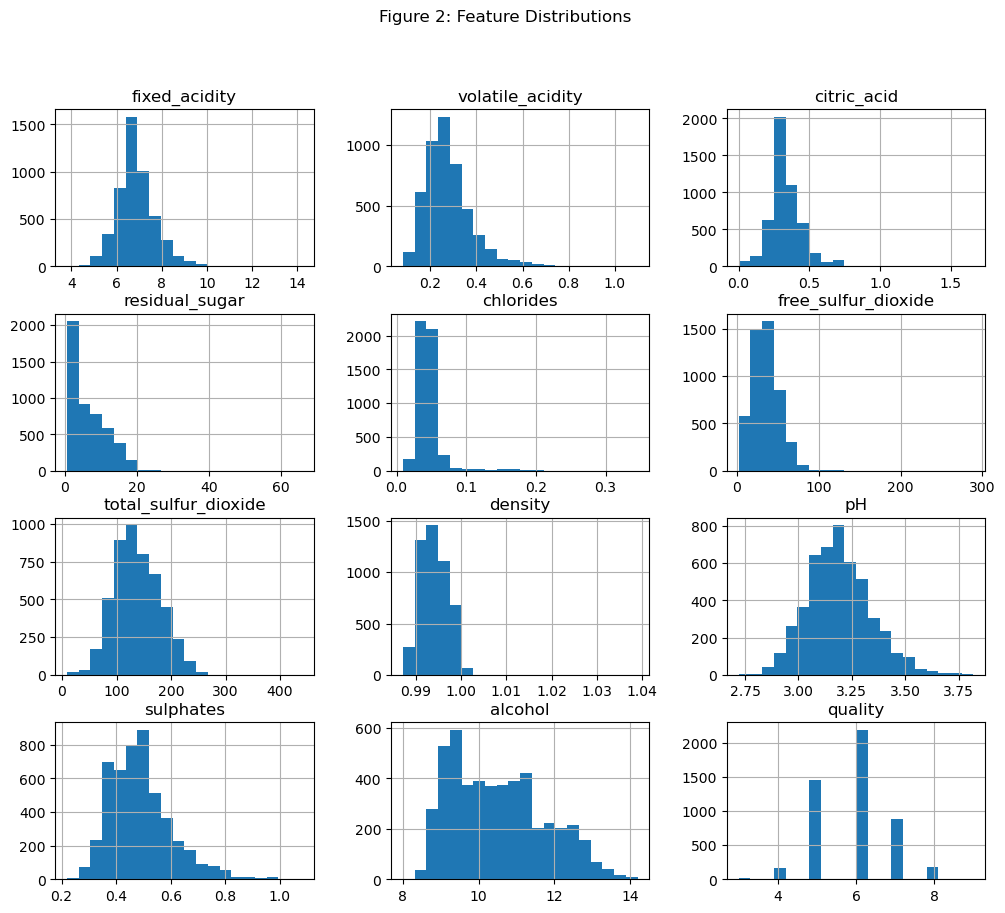

In [8]:
df.hist(bins=20, figsize=(12,10))
plt.suptitle("Figure 2: Feature Distributions")
plt.show()

Figure 2 show that most physicochemical variables fall within fairly narrow ranges. For example, pH values are centered around 3.2 with a small spread, and density is close to 0.995 for most wines. Alcohol content ranges roughly from 8% to 15%, with an average around 10.5%. In contrast, residual sugar varies much more widely, ranging from under 1 to over 60, indicating some extreme observations.

The figure also suggests that several variables are right-skewed, meaning most wines have lower values with a few much larger observations. This pattern is especially noticeable for chlorides, residual sugar, sulphates, and fixed acidity. Total sulfur dioxide appears roughly more evenly distributed around the average.

#### Correlation matrix

We compute the correlation matrix using `df.corr()` to measure the linear relationships between all numerical variables in the dataset. The matrix is then visualized using `plt.imshow()`, where each cell represents the correlation between two variables.

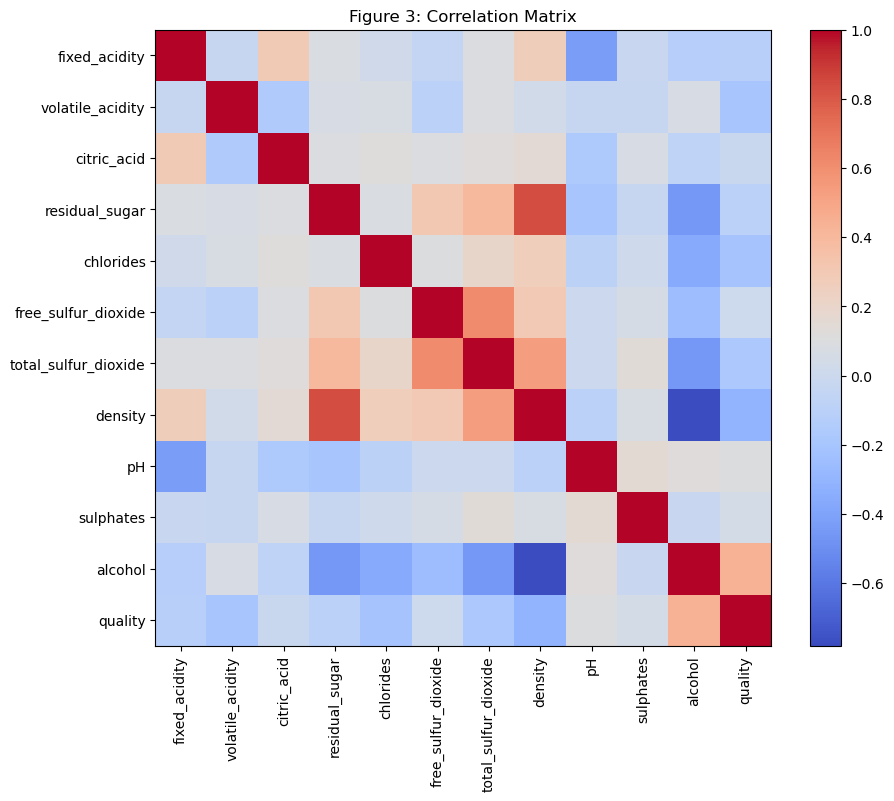

In [9]:
corr = df.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm", interpolation="none")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Figure 3: Correlation Matrix")
plt.show()

Figure 3 shows the strength and direction of linear relationships between the variables. Overall, most physicochemical features have relatively weak correlations with wine quality, suggesting that quality is influenced by multiple factors rather than a single dominant variable. Alcohol content tends to have a positive relationship with quality, while variables such as volatile acidity and density show negative relationships. Many of the input variables also show moderate correlations with each other, indicating that some chemical properties of the wine are related.

### Prediction

In [10]:
# split target with other features
X = df.drop(columns=['quality'])
y = df['quality']

# define train, validation, and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=123)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.21, shuffle=True, random_state=123)

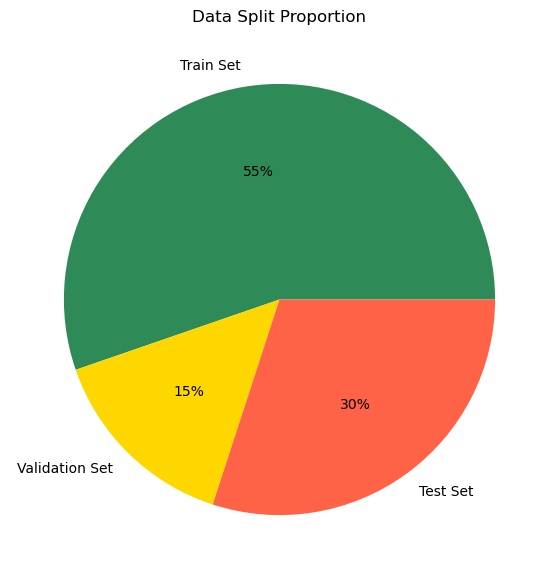

Train set length: 2708 | Validation set length: 720 | Test set length: 1470



In [11]:
# compute size for each dataset
data_size = len(df)
train_set_size = len(X_train) / data_size
valid_set_size = len(X_valid) / data_size
test_set_size = len(X_test) / data_size

# plot pie chart
plt.figure(figsize=(7, 7))
pie_colors = ['seagreen', 'gold', 'tomato']

plt.pie(
    [train_set_size, valid_set_size, test_set_size],
    labels=['Train Set', 'Validation Set', 'Test Set'],
    colors=pie_colors,
    autopct='%1.0f%%'
)

plt.title('Data Split Proportion')
plt.show()

print(f"Train set length: {len(X_train)} | Validation set length: {len(X_valid)} | Test set length: {len(X_test)}\n")

In [12]:
# define random forest model
rf_model = RandomForestClassifier(random_state=123)

# define param grid for gird search
param_grid = {
    'n_estimators': [10, 50, 100, 200, 400],
    'max_depth': [2, 10, 20, 30, 40, 50]
}

grid_search = GridSearchCV(rf_model, param_grid, cv=2, return_train_score=True, n_jobs=-1)

In [13]:
# fit grid search
grid_search.fit(X_train, y_train)

# print best params
print(f'Best parameters found from grid search: {grid_search.best_params_}')

Best parameters found from grid search: {'max_depth': 20, 'n_estimators': 100}


In [14]:
# retrieve best performing model
best_model = grid_search.best_estimator_

# predict on test data
pred = best_model.predict(X_test)

In [15]:
train_pred = best_model.predict(X_train)

print(f'Train Accuracy: {round(accuracy_score(train_pred, y_train), 3)}')
print(f'Validation Accuracy: {round(grid_search.best_score_, 3)}')

Train Accuracy: 1.0
Validation Accuracy: 0.606


In [16]:
print(f'Test Accuracy: {round(accuracy_score(pred, y_test), 3)}')
print(f'Test Precision: {round(precision_score(pred, y_test, average='macro', zero_division=0), 3)}')
print(f'Test Recall: {round(recall_score(pred, y_test, average='macro', zero_division=0), 3)}')
print(f'Test F1-Score: {round(f1_score(pred, y_test, average='macro', zero_division=0), 3)}')

Test Accuracy: 0.648
Test Precision: 0.345
Test Recall: 0.495
Test F1-Score: 0.378


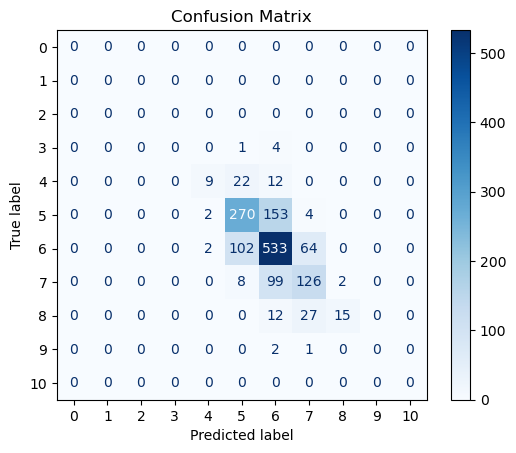

In [17]:
labels = [i for i in range(11)]

cm = confusion_matrix(y_test, pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

<br>

## Discussion

The exploratory data analysis suggests that most wines in the dataset fall into average quality categories, with ratings concentrated around the middle of the scale. This indicates that extremely high or low quality wines are relatively uncommon. The distributions of many physicochemical variables show that most measurements lie within typical ranges, although some variables such as residual sugar and chlorides exhibit wider spreads and occasional extreme values. Several variables also appear right-skewed, meaning most wines have relatively small values with a few larger observations. This pattern suggests that certain chemical properties occur at low levels for most wines but can occasionally be much higher. The correlation analysis further indicates that no single variable strongly determines wine quality. Instead, wine quality appears to be influenced by a combination of multiple chemical characteristics, with some variables showing modest positive or negative relationships with the quality score.

## References

[1] Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. Decision Support Systems. https://archive-beta.ics.uci.edu/dataset/186/wine+quality

[2] Wikipedia contributors. (2025). Vinho Verde. https://en.wikipedia.org/wiki/Vinho_Verde